
 >>> Processing Noise Level: Sigma = 15 <<<
Loading training data from folders for Sigma=15...
Training SVR (Samples: 10000)...
Training Done.


Inference: 100%|██████████| 31/31 [00:29<00:00,  1.05it/s]



 >>> Processing Noise Level: Sigma = 25 <<<
Loading training data from folders for Sigma=25...
Training SVR (Samples: 10000)...
Training Done.


Inference: 100%|██████████| 31/31 [00:35<00:00,  1.16s/it]



 >>> Processing Noise Level: Sigma = 50 <<<
Loading training data from folders for Sigma=50...
Training SVR (Samples: 10000)...
Training Done.


Inference: 100%|██████████| 31/31 [00:43<00:00,  1.41s/it]



Generating combined result image...
Combined image saved to: svr_bsd68_combined_results.png


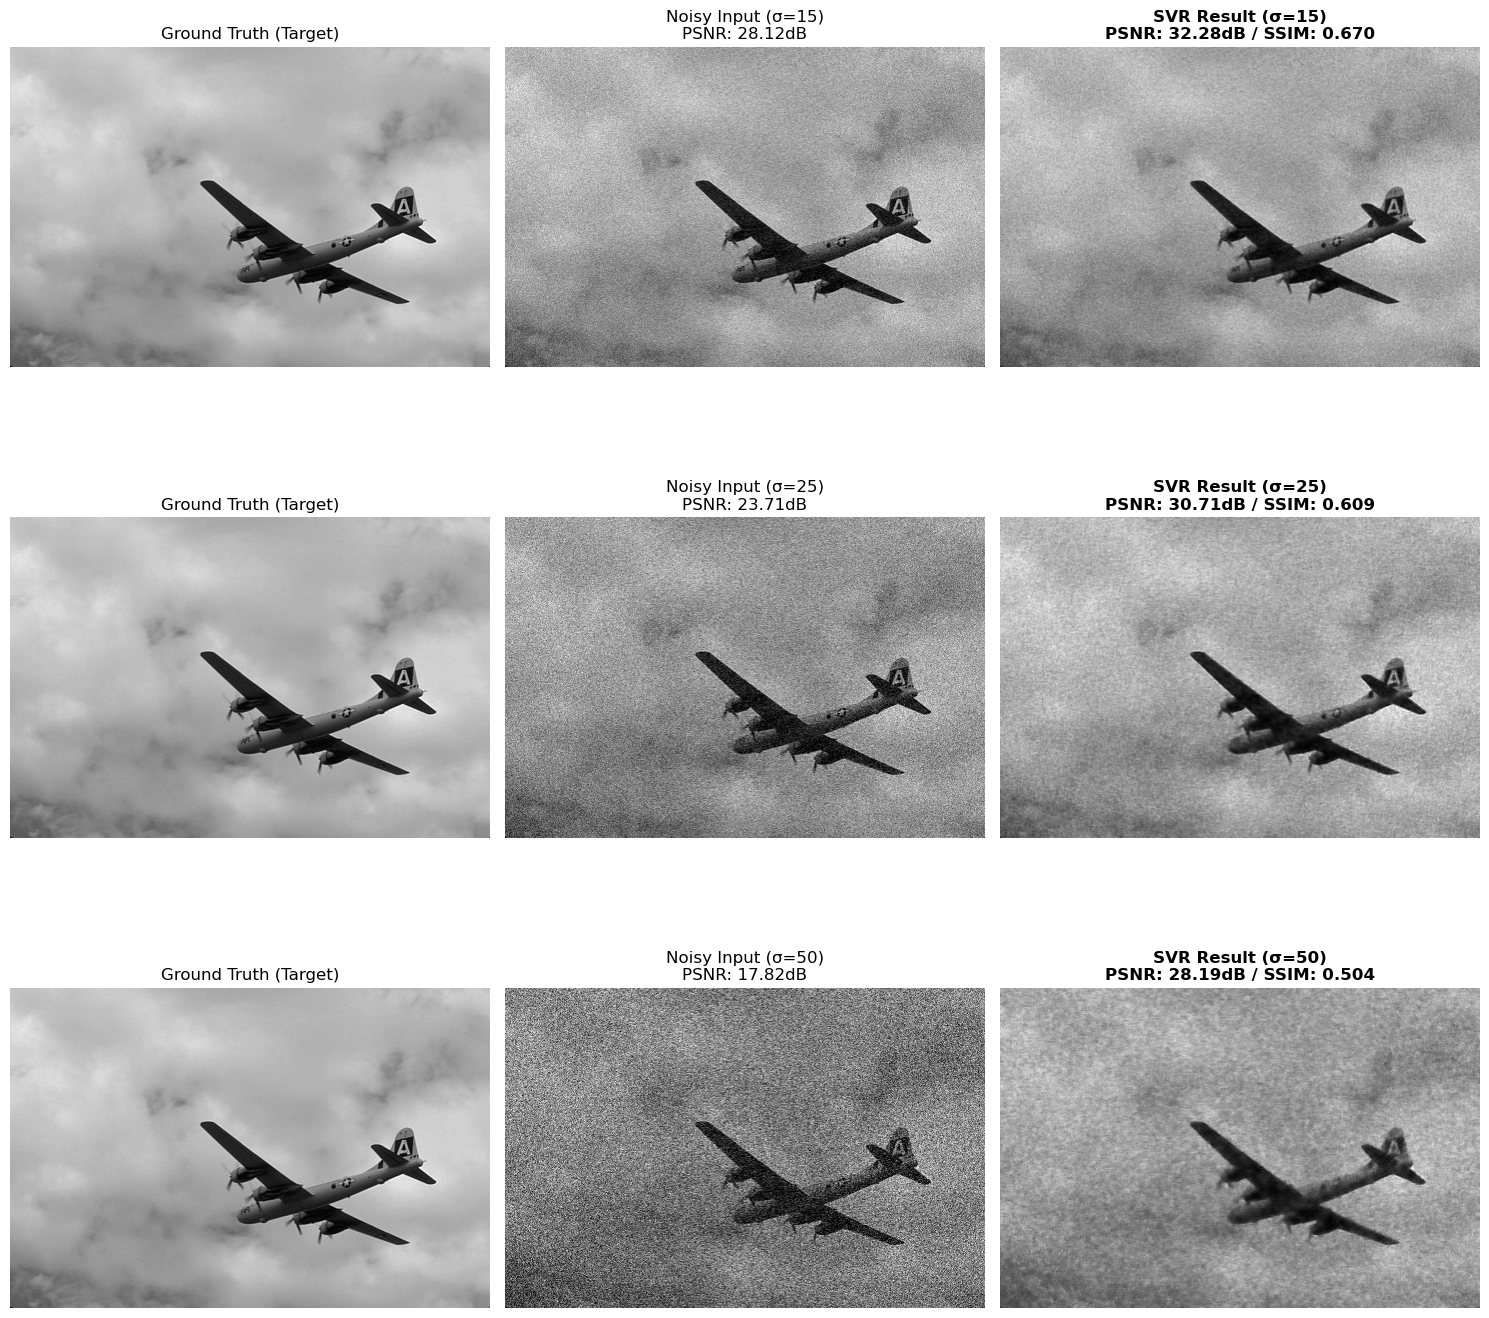

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.feature_extraction.image import extract_patches_2d
from skimage.util import view_as_windows
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

# ============================
# Configuration
# ============================
BSD68_ROOT = "data/BSD68" 
SIGMA_LIST = [15, 25, 50]
PATCH_SIZE = 7
NUM_TRAIN_PATCHES = 10000 

# ============================
# Helper Functions
# ============================
def get_image_paths(root_dir, subfolder):
    full_path = os.path.join(root_dir, subfolder)
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"Folder not found: {full_path}")
    files = sorted([f for f in os.listdir(full_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return [os.path.join(full_path, f) for f in files]

def load_training_data_from_folders(root_dir, sigma, num_patches=5000, patch_size=7):
    print(f"Loading training data from folders for Sigma={sigma}...")
    clean_folder = "original_png" if os.path.exists(os.path.join(root_dir, "original_png")) else "original"
    noisy_folder = f"noisy{sigma}"
    
    clean_paths = get_image_paths(root_dir, clean_folder)
    noisy_paths = get_image_paths(root_dir, noisy_folder)
    
    if len(clean_paths) != len(noisy_paths):
        raise ValueError("Mismatch in number of images!")
        
    X_train = []
    y_train = []
    
    patches_collected = 0
    max_attempts = num_patches * 5
    attempts = 0
    
    while patches_collected < num_patches and attempts < max_attempts:
        attempts += 1
        idx = np.random.randint(0, len(clean_paths))
        
        img_clean = cv2.imread(clean_paths[idx], cv2.IMREAD_GRAYSCALE)
        img_noisy = cv2.imread(noisy_paths[idx], cv2.IMREAD_GRAYSCALE)
        
        if img_clean is None or img_noisy is None: continue
        
        img_clean = img_clean.astype(np.float32) / 255.0
        img_noisy = img_noisy.astype(np.float32) / 255.0
        
        h, w = img_clean.shape
        if h <= patch_size or w <= patch_size: continue
        
        r = np.random.randint(0, h - patch_size)
        c = np.random.randint(0, w - patch_size)
        
        patch_noisy = img_noisy[r:r+patch_size, c:c+patch_size]
        pixel_clean = img_clean[r+patch_size//2, c+patch_size//2]
        
        X_train.append(patch_noisy.flatten())
        y_train.append(pixel_clean)
        patches_collected += 1
        
    return np.array(X_train), np.array(y_train)

class SVRDenoiser:
    def __init__(self, C=10, epsilon=0.02, gamma=0.05):
        self.model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
        self.patch_size = 7
        
    def train(self, X, y):
        print(f"Training SVR (Samples: {len(X)})...")
        self.model.fit(X, y)
        print("Training Done.")
        
    def predict(self, noisy_img):
        h, w = noisy_img.shape
        pad = self.patch_size // 2
        img_padded = np.pad(noisy_img, ((pad, pad), (pad, pad)), mode='symmetric')
        windows = view_as_windows(img_padded, (self.patch_size, self.patch_size))
        X_test = windows.reshape(h * w, -1)
        
        batch_size = 5000
        preds = []
        for i in tqdm(range(0, len(X_test), batch_size), desc="Inference"):
            preds.append(self.model.predict(X_test[i:i+batch_size]))
            
        return np.concatenate(preds).reshape(h, w)

# ============================
# Main Logic
# ============================
if __name__ == "__main__":
    if not os.path.exists(BSD68_ROOT):
        print(f"Error: {BSD68_ROOT} not found.")
        exit()

    # Store results for final combined plot
    # Structure: [ (sigma, img_gt, img_noisy, img_denoised, psnr_noisy, psnr_denoised, ssim_denoised), ... ]
    results_buffer = []

    for sigma in SIGMA_LIST:
        print(f"\n{'='*60}")
        print(f" >>> Processing Noise Level: Sigma = {sigma} <<<")
        print(f"{'='*60}")
        
        # 1. Train
        try:
            X_train, y_train = load_training_data_from_folders(
                BSD68_ROOT, sigma, num_patches=NUM_TRAIN_PATCHES
            )
        except Exception as e:
            print(f"Skipping Sigma={sigma} due to error: {e}")
            continue
            
        svr = SVRDenoiser()
        svr.train(X_train, y_train)
        
        # 2. Test (Using the first image as visual sample)
        clean_folder = "original_png" if os.path.exists(os.path.join(BSD68_ROOT, "original_png")) else "original"
        noisy_folder = f"noisy{sigma}"
        
        test_clean_path = get_image_paths(BSD68_ROOT, clean_folder)[0]
        test_noisy_path = get_image_paths(BSD68_ROOT, noisy_folder)[0]
        
        img_gt = cv2.imread(test_clean_path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        img_noisy_input = cv2.imread(test_noisy_path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

        # 3. Inference
        img_denoised = svr.predict(img_noisy_input)
        
        # 4. Metrics
        psnr_noisy = psnr(img_gt, img_noisy_input, data_range=1.0)
        val_psnr = psnr(img_gt, img_denoised, data_range=1.0)
        val_ssim = ssim(img_gt, img_denoised, data_range=1.0)
        
        # 5. Store data
        results_buffer.append({
            'sigma': sigma,
            'clean': img_gt,
            'noisy': img_noisy_input,
            'denoised': img_denoised,
            'psnr_noisy': psnr_noisy,
            'psnr_denoised': val_psnr,
            'ssim_denoised': val_ssim
        })

    # ============================
    # Generate Combined Plot
    # ============================
    print("\nGenerating combined result image...")
    
    rows = len(results_buffer)
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    
    # If only one sigma, axes is 1D array, make it 2D for consistency
    if rows == 1:
        axes = [axes]

    for i, res in enumerate(results_buffer):
        sigma = res['sigma']
        
        # Column 1: Ground Truth
        ax_clean = axes[i][0]
        ax_clean.imshow(res['clean'], cmap='gray')
        ax_clean.set_title(f"Ground Truth (Target)", fontsize=12)
        ax_clean.axis('off')
        
        # Column 2: Noisy Input
        ax_noisy = axes[i][1]
        ax_noisy.imshow(res['noisy'], cmap='gray')
        ax_noisy.set_title(f"Noisy Input (σ={sigma})\nPSNR: {res['psnr_noisy']:.2f}dB", fontsize=12)
        ax_noisy.axis('off')
        
        # Column 3: SVR Result
        ax_denoised = axes[i][2]
        ax_denoised.imshow(res['denoised'], cmap='gray')
        ax_denoised.set_title(f"SVR Result (σ={sigma})\nPSNR: {res['psnr_denoised']:.2f}dB / SSIM: {res['ssim_denoised']:.3f}", fontsize=12, fontweight='bold')
        ax_denoised.axis('off')

    plt.tight_layout()
    save_path = "svr_bsd68_combined_results.png"
    plt.savefig(save_path)
    print(f"Combined image saved to: {save_path}")
    plt.show()


 >>> Processing Noise Level: Sigma = 15 <<<
Loading training data from folders for Sigma=15...
Training SVR (Samples: 10000)...
Training Done.


Inference: 100%|██████████| 31/31 [00:29<00:00,  1.05it/s]



 >>> Processing Noise Level: Sigma = 25 <<<
Loading training data from folders for Sigma=25...
Training SVR (Samples: 10000)...
Training Done.


Inference: 100%|██████████| 31/31 [00:35<00:00,  1.16s/it]



 >>> Processing Noise Level: Sigma = 50 <<<
Loading training data from folders for Sigma=50...
Training SVR (Samples: 10000)...
Training Done.


Inference: 100%|██████████| 31/31 [00:43<00:00,  1.41s/it]



Generating combined result image...
Combined image saved to: svr_bsd68_combined_results.png


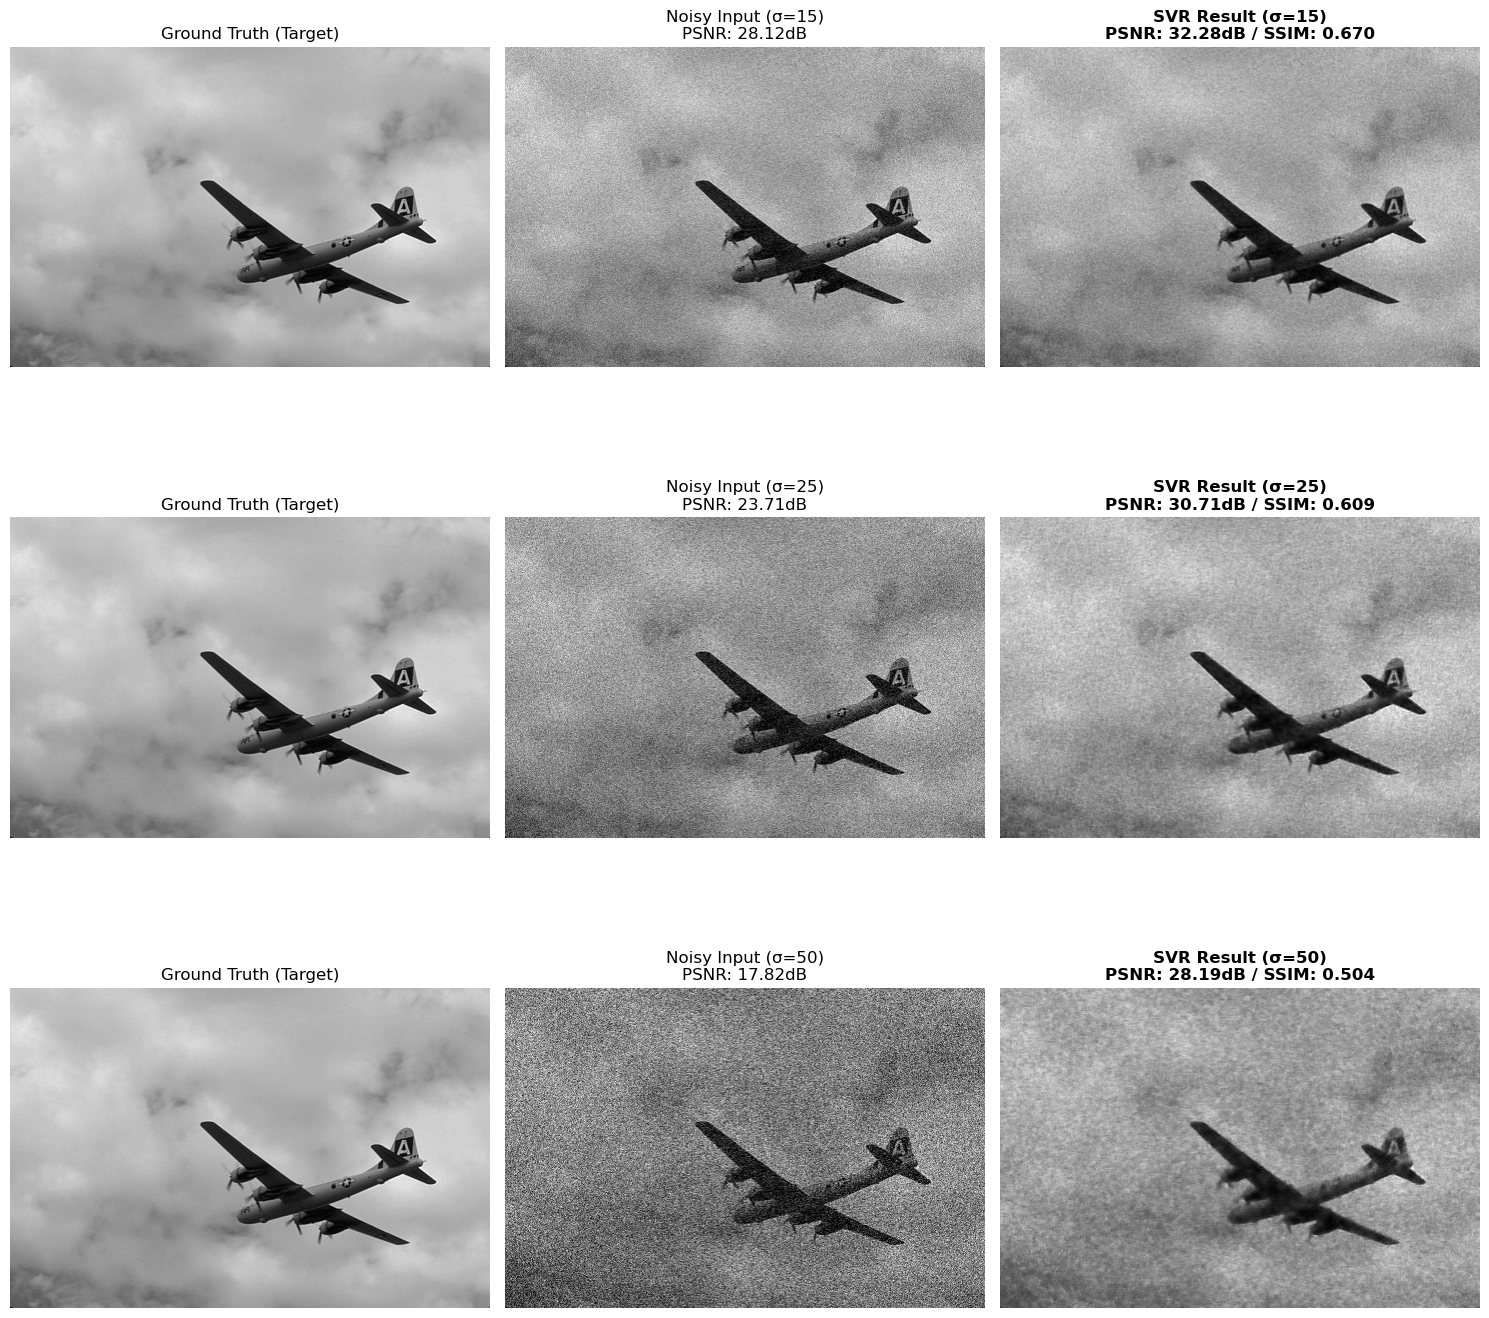

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.feature_extraction.image import extract_patches_2d
from skimage.util import view_as_windows
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

# ============================
# Configuration
# ============================
BSD68_ROOT = "data/BSD68" 
SIGMA_LIST = [15, 25, 50]
PATCH_SIZE = 7
NUM_TRAIN_PATCHES = 10000 

# ============================
# Helper Functions
# ============================
def get_image_paths(root_dir, subfolder):
    full_path = os.path.join(root_dir, subfolder)
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"Folder not found: {full_path}")
    files = sorted([f for f in os.listdir(full_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return [os.path.join(full_path, f) for f in files]

def load_training_data_from_folders(root_dir, sigma, num_patches=5000, patch_size=7):
    print(f"Loading training data from folders for Sigma={sigma}...")
    clean_folder = "original_png" if os.path.exists(os.path.join(root_dir, "original_png")) else "original"
    noisy_folder = f"noisy{sigma}"
    
    clean_paths = get_image_paths(root_dir, clean_folder)
    noisy_paths = get_image_paths(root_dir, noisy_folder)
    
    if len(clean_paths) != len(noisy_paths):
        raise ValueError("Mismatch in number of images!")
        
    X_train = []
    y_train = []
    
    patches_collected = 0
    max_attempts = num_patches * 5
    attempts = 0
    
    while patches_collected < num_patches and attempts < max_attempts:
        attempts += 1
        idx = np.random.randint(0, len(clean_paths))
        
        img_clean = cv2.imread(clean_paths[idx], cv2.IMREAD_GRAYSCALE)
        img_noisy = cv2.imread(noisy_paths[idx], cv2.IMREAD_GRAYSCALE)
        
        if img_clean is None or img_noisy is None: continue
        
        img_clean = img_clean.astype(np.float32) / 255.0
        img_noisy = img_noisy.astype(np.float32) / 255.0
        
        h, w = img_clean.shape
        if h <= patch_size or w <= patch_size: continue
        
        r = np.random.randint(0, h - patch_size)
        c = np.random.randint(0, w - patch_size)
        
        patch_noisy = img_noisy[r:r+patch_size, c:c+patch_size]
        pixel_clean = img_clean[r+patch_size//2, c+patch_size//2]
        
        X_train.append(patch_noisy.flatten())
        y_train.append(pixel_clean)
        patches_collected += 1
        
    return np.array(X_train), np.array(y_train)

class SVRDenoiser:
    def __init__(self, C=10, epsilon=0.02, gamma=0.05):
        self.model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
        self.patch_size = 7
        
    def train(self, X, y):
        print(f"Training SVR (Samples: {len(X)})...")
        self.model.fit(X, y)
        print("Training Done.")
        
    def predict(self, noisy_img):
        h, w = noisy_img.shape
        pad = self.patch_size // 2
        img_padded = np.pad(noisy_img, ((pad, pad), (pad, pad)), mode='symmetric')
        windows = view_as_windows(img_padded, (self.patch_size, self.patch_size))
        X_test = windows.reshape(h * w, -1)
        
        batch_size = 5000
        preds = []
        for i in tqdm(range(0, len(X_test), batch_size), desc="Inference"):
            preds.append(self.model.predict(X_test[i:i+batch_size]))
            
        return np.concatenate(preds).reshape(h, w)

# ============================
# Main Logic
# ============================
if __name__ == "__main__":
    if not os.path.exists(BSD68_ROOT):
        print(f"Error: {BSD68_ROOT} not found.")
        exit()

    # Store results for final combined plot
    # Structure: [ (sigma, img_gt, img_noisy, img_denoised, psnr_noisy, psnr_denoised, ssim_denoised), ... ]
    results_buffer = []

    for sigma in SIGMA_LIST:
        print(f"\n{'='*60}")
        print(f" >>> Processing Noise Level: Sigma = {sigma} <<<")
        print(f"{'='*60}")
        
        # 1. Train
        try:
            X_train, y_train = load_training_data_from_folders(
                BSD68_ROOT, sigma, num_patches=NUM_TRAIN_PATCHES
            )
        except Exception as e:
            print(f"Skipping Sigma={sigma} due to error: {e}")
            continue
            
        svr = SVRDenoiser()
        svr.train(X_train, y_train)
        
        # 2. Test (Using the first image as visual sample)
        clean_folder = "original_png" if os.path.exists(os.path.join(BSD68_ROOT, "original_png")) else "original"
        noisy_folder = f"noisy{sigma}"
        
        test_clean_path = get_image_paths(BSD68_ROOT, clean_folder)[0]
        test_noisy_path = get_image_paths(BSD68_ROOT, noisy_folder)[0]
        
        img_gt = cv2.imread(test_clean_path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        img_noisy_input = cv2.imread(test_noisy_path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

        # 3. Inference
        img_denoised = svr.predict(img_noisy_input)
        
        # 4. Metrics
        psnr_noisy = psnr(img_gt, img_noisy_input, data_range=1.0)
        val_psnr = psnr(img_gt, img_denoised, data_range=1.0)
        val_ssim = ssim(img_gt, img_denoised, data_range=1.0)
        
        # 5. Store data
        results_buffer.append({
            'sigma': sigma,
            'clean': img_gt,
            'noisy': img_noisy_input,
            'denoised': img_denoised,
            'psnr_noisy': psnr_noisy,
            'psnr_denoised': val_psnr,
            'ssim_denoised': val_ssim
        })

    # ============================
    # Generate Combined Plot
    # ============================
    print("\nGenerating combined result image...")
    
    rows = len(results_buffer)
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    
    # If only one sigma, axes is 1D array, make it 2D for consistency
    if rows == 1:
        axes = [axes]

    for i, res in enumerate(results_buffer):
        sigma = res['sigma']
        
        # Column 1: Ground Truth
        ax_clean = axes[i][0]
        ax_clean.imshow(res['clean'], cmap='gray')
        ax_clean.set_title(f"Ground Truth (Target)", fontsize=12)
        ax_clean.axis('off')
        
        # Column 2: Noisy Input
        ax_noisy = axes[i][1]
        ax_noisy.imshow(res['noisy'], cmap='gray')
        ax_noisy.set_title(f"Noisy Input (σ={sigma})\nPSNR: {res['psnr_noisy']:.2f}dB", fontsize=12)
        ax_noisy.axis('off')
        
        # Column 3: SVR Result
        ax_denoised = axes[i][2]
        ax_denoised.imshow(res['denoised'], cmap='gray')
        ax_denoised.set_title(f"SVR Result (σ={sigma})\nPSNR: {res['psnr_denoised']:.2f}dB / SSIM: {res['ssim_denoised']:.3f}", fontsize=12, fontweight='bold')
        ax_denoised.axis('off')

    plt.tight_layout()
    save_path = "svr_bsd68_combined_results.png"
    plt.savefig(save_path)
    print(f"Combined image saved to: {save_path}")
    plt.show()